In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv('../data/transactions.csv')
print(df.shape)
print(df.dtypes)
df.head()

(299695, 17)
transaction_id               int64
user_id                      int64
account_age_days             int64
total_transactions_user      int64
avg_amount_user            float64
amount                     float64
country                     object
bin_country                 object
channel                     object
merchant_category           object
promo_used                   int64
avs_match                    int64
cvv_result                   int64
three_ds_flag                int64
transaction_time            object
shipping_distance_km       float64
is_fraud                     int64
dtype: object


,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [2]:
## setting up the transction time to 
sns.set_theme(style='darkgrid')
df['transaction_time'] = pd.to_datetime(df['transaction_time'])
df['hour'] = df['transaction_time'].dt.hour
df['day_of_week'] = df['transaction_time'].dt.dayofweek
df['month'] = df['transaction_time'].dt.month

print("=== SHAPE ===")
print(df.shape)

print("\n=== NULLS ===")
print(df.isnull().sum())

print("\n=== FRAUD RATE ===")
fraud_rate = df['is_fraud'].mean() * 100
print(f"{fraud_rate:.2f}% of transactions are fraudulent")
print(f"Fraud: {df['is_fraud'].sum():,} | Legit: {(df['is_fraud']==0).sum():,}")

=== SHAPE ===
(299695, 20)

=== NULLS ===
transaction_id             0
user_id                    0
account_age_days           0
total_transactions_user    0
avg_amount_user            0
amount                     0
country                    0
bin_country                0
channel                    0
merchant_category          0
promo_used                 0
avs_match                  0
cvv_result                 0
three_ds_flag              0
transaction_time           0
shipping_distance_km       0
is_fraud                   0
hour                       0
day_of_week                0
month                      0
dtype: int64

=== FRAUD RATE ===
2.21% of transactions are fraudulent
Fraud: 6,612 | Legit: 293,083


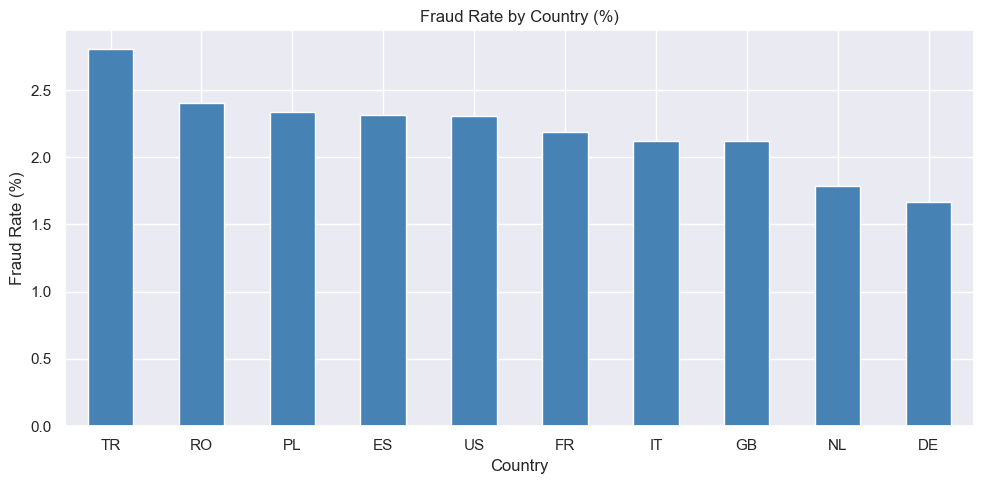

country
TR    2.80
RO    2.40
PL    2.34
ES    2.31
US    2.31
FR    2.19
IT    2.12
GB    2.12
NL    1.78
DE    1.67
Name: is_fraud, dtype: float64


In [3]:
## Fraud Rate by Country
## goal: see which countries have the highest % of fraudulent transactions

# create a blank canvas to draw the chart on (10 wide, 5 tall in inches)
fig, ax = plt.subplots(figsize=(10, 5))

# group all transactions by country, then calculate the mean of is_fraud (0s and 1s)
# multiply by 100 to convert to percentage, sort highest to lowest
fraud_by_country = df.groupby('country')['is_fraud'].mean().sort_values(ascending=False) * 100

# draw a bar chart on our canvas using the data above
fraud_by_country.plot(kind='bar', ax=ax, color='steelblue')

# add a title and axis labels so the chart is readable
ax.set_title('Fraud Rate by Country (%)')
ax.set_xlabel('Country')
ax.set_ylabel('Fraud Rate (%)')

# rotate the country name labels 45 degrees so they dont overlap
ax.tick_params(axis='x', rotation=0)

# automatically adjust spacing so nothing gets cut off
plt.tight_layout()

# render and display the chart
plt.show()

# also print the exact numbers below the chart
print(fraud_by_country.round(2))

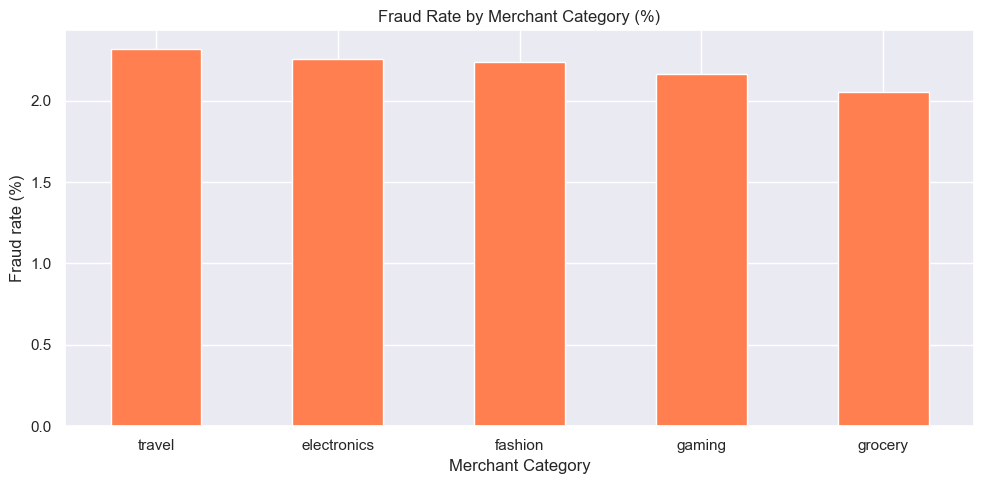

merchant_category
travel         2.0
electronics    2.0
fashion        2.0
gaming         2.0
grocery        2.0
Name: is_fraud, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(10,5))

fraud_by_merchant = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False) * 100

fraud_by_merchant.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Fraud Rate by Merchant Category (%)')
ax.set_xlabel('Merchant Category')
ax.set_ylabel('Fraud rate (%)')

ax.tick_params(axis='x', rotation=0)

plt.tight_layout()

plt.show()

print(fraud_by_merchant.round())

# from this we figure that there isnt a correlation between fraud rate and merchant category


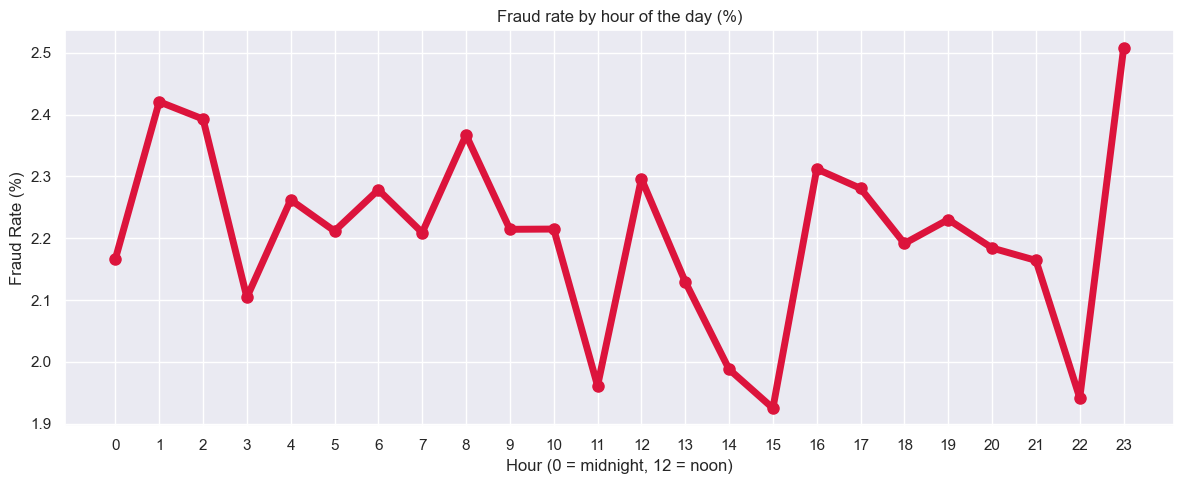

hour
0     2.17
1     2.42
2     2.39
3     2.10
4     2.26
5     2.21
6     2.28
7     2.21
8     2.37
9     2.21
10    2.21
11    1.96
12    2.30
13    2.13
14    1.99
15    1.93
16    2.31
17    2.28
18    2.19
19    2.23
20    2.18
21    2.16
22    1.94
23    2.51
Name: is_fraud, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(12,5))

fraud_by_hour = df.groupby('hour')['is_fraud'].mean().sort_index() * 100

fraud_by_hour.plot(kind='line', ax=ax, color ='crimson', linewidth=5, marker='o', markersize=8)

ax.set_title('Fraud rate by hour of the day (%)')
ax.set_xlabel('Hour (0 = midnight, 12 = noon)')
ax.set_ylabel('Fraud Rate (%)')

ax.set_xticks(range(0, 24))
plt.tight_layout()

plt.show()

print(fraud_by_hour.round(2))

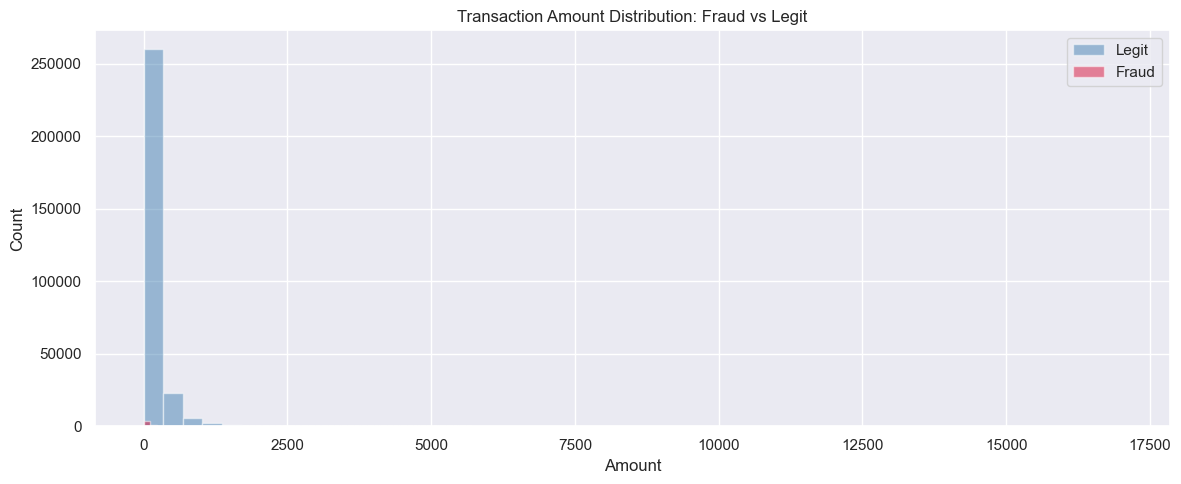

             count    mean     std  min    25%     50%      75%       max
is_fraud                                                                 
0         293083.0  167.83  273.64  5.0  42.35   89.84   189.06  16994.74
1           6612.0  590.96  880.75  1.0  21.32  103.16  1061.12   5716.46


In [6]:
## Transaction Amount: Fraud vs Legit
## goal: see if fraudulent transactions tend to be higher or lower amounts

fig, ax = plt.subplots(figsize=(12, 5))

# plot two overlapping histograms
df[df['is_fraud'] == 0]['amount'].hist(bins=50, alpha=0.5, label='Legit', color='steelblue', ax=ax)
df[df['is_fraud'] == 1]['amount'].hist(bins=50, alpha=0.5, label='Fraud', color='crimson', ax=ax)

ax.set_title('Transaction Amount Distribution: Fraud vs Legit')
ax.set_xlabel('Amount')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

# print summary stats
print(df.groupby('is_fraud')['amount'].describe().round(2))

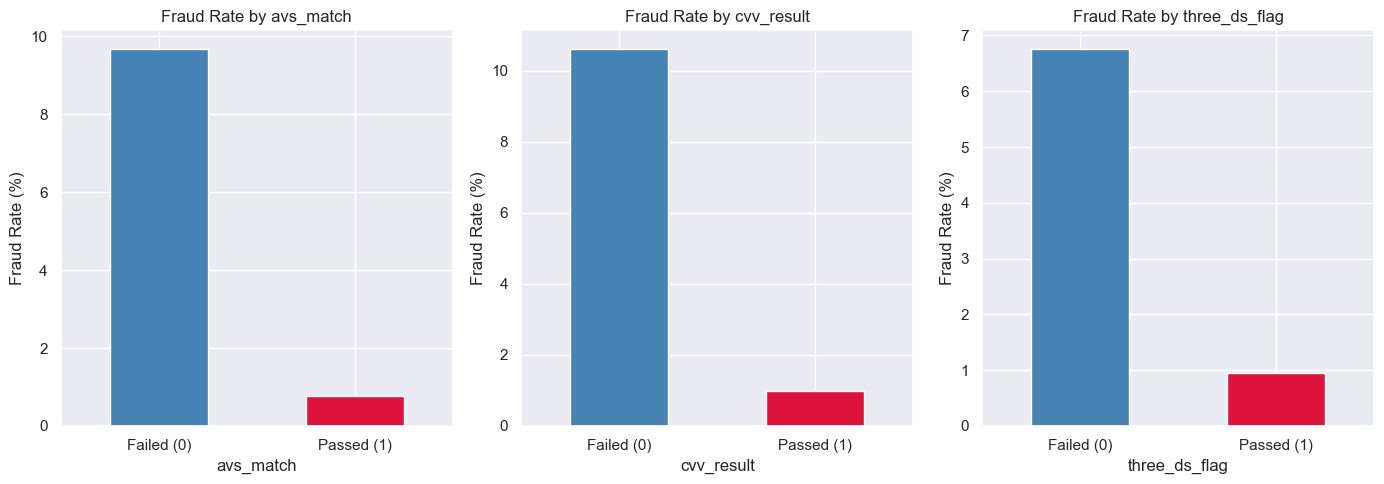

In [7]:
## Security Flags vs Fraud Rate
## goal: see if failed security checks correlate with fraud

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# check each security flag
for ax, col in zip(axes, ['avs_match', 'cvv_result', 'three_ds_flag']):
    fraud_by_flag = df.groupby(col)['is_fraud'].mean() * 100
    fraud_by_flag.plot(kind='bar', ax=ax, color=['steelblue', 'crimson'])
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_xticklabels(['Failed (0)', 'Passed (1)'], rotation=0)

plt.tight_layout()
plt.show()

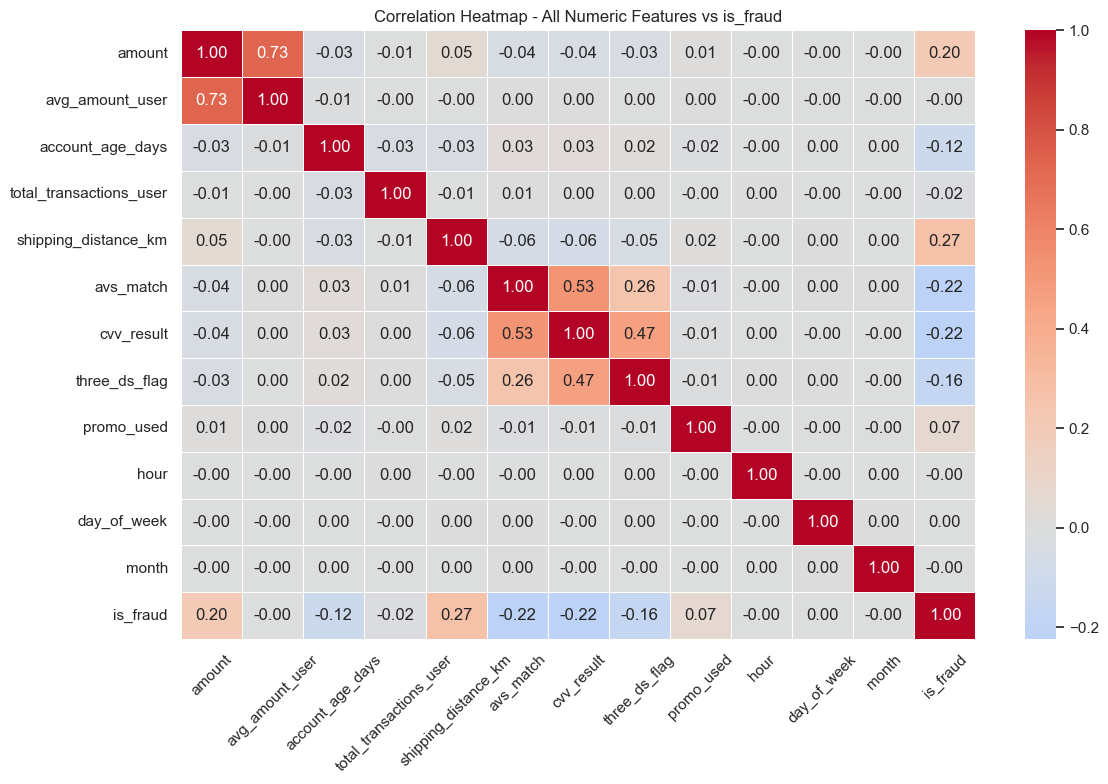

In [8]:
## Correlation Heatmap
## goal: see which numeric features have the strongest relationship with is_fraud

fig, ax = plt.subplots(figsize=(12, 8))

# select only numeric columns
numeric_cols = ['amount', 'avg_amount_user', 'account_age_days', 
                'total_transactions_user', 'shipping_distance_km',
                'avs_match', 'cvv_result', 'three_ds_flag', 
                'promo_used', 'hour', 'day_of_week', 'month', 'is_fraud']

# calculate correlation between all numeric columns
corr_matrix = df[numeric_cols].corr()

# draw the heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, linewidths=0.5)

ax.set_title('Correlation Heatmap - All Numeric Features vs is_fraud')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [9]:
##Conclsuion

## The strongest correlation between fraud is shipping_distance, (avs_match, cvv_result and three_ds_flag) if a user fails any one of these 
## then the trnsactions would be likely to be fraud
## some other big factors are the account age and the amount of the transaciton
## so the conclusion is that there is a correlation between all of these and is_fraud 

In [10]:
## Isolating high risk transactions based on hypothesis
## goal: test if combining all risk factors produces a much higher fraud rate

# define high risk conditions based on our hypothesis
high_risk = df[
    (df['cvv_result'] == 0) &          # failed CVV
    (df['avs_match'] == 0) &           # failed AVS
    (df['three_ds_flag'] == 0) &       # failed 3DS
    (df['amount'] > df['amount'].quantile(0.75)) &          # top 25% transaction amount
    (df['account_age_days'] < df['account_age_days'].quantile(0.25))  # bottom 25% account age (newest accounts)
]

# compare fraud rate in high risk group vs overall
overall_fraud_rate = df['is_fraud'].mean() * 100
high_risk_fraud_rate = high_risk['is_fraud'].mean() * 100

print(f"Overall fraud rate:    {overall_fraud_rate:.2f}%")
print(f"High risk group fraud rate: {high_risk_fraud_rate:.2f}%")
print(f"Multiplier: {high_risk_fraud_rate / overall_fraud_rate:.1f}x more likely")
print(f"High risk transactions: {len(high_risk):,} out of {len(df):,}")

Overall fraud rate:    2.21%
High risk group fraud rate: 44.71%
Multiplier: 20.3x more likely
High risk transactions: 1,684 out of 299,695


In [11]:
# ── 1. Country mismatch flag ──────────────────────────────
# if the card was issued in a different country than the transaction → suspicious
df['country_mismatch'] = (df['country'] != df['bin_country']).astype(int)

# ── 2. Security fails score ───────────────────────────────
# count how many of the 3 security checks failed (0, 1, 2, or 3)
# 3 = all failed = highest risk
df['security_fails'] = (
    (1 - df['avs_match']) +
    (1 - df['cvv_result']) +
    (1 - df['three_ds_flag'])
)

# ── 3. Amount vs user average ratio ──────────────────────
# is this transaction unusually large compared to what this user normally spends?
# 2.0 means this transaction is 2x their normal amount
df['amount_vs_avg'] = df['amount'] / (df['avg_amount_user'] + 1)

# ── 4. High risk flag ────────────────────────────────────
# encode our validated hypothesis directly as a feature
df['is_high_risk'] = (
    (df['cvv_result'] == 0) &
    (df['avs_match'] == 0) &
    (df['three_ds_flag'] == 0) &
    (df['amount'] > df['amount'].quantile(0.75)) &
    (df['account_age_days'] < df['account_age_days'].quantile(0.25))
).astype(int)

# ── 5. Encode text columns ───────────────────────────────
# convert country, channel, merchant_category from text to numbers
# pd.get_dummies creates a separate 0/1 column for each category
df = pd.get_dummies(df, columns=['country', 'bin_country', 'channel', 'merchant_category'])

print("New shape:", df.shape)
print("\nNew features added:")
print([c for c in df.columns if c in ['country_mismatch', 'security_fails', 'amount_vs_avg', 'is_high_risk']])

print("Shape:", df.shape)
print("\nNew features sample:")
print(df[['amount_vs_avg', 'security_fails', 'country_mismatch', 'is_high_risk']].head())
print("\nHigh risk transactions:", df['is_high_risk'].sum())
print("Security fails distribution:\n", df['security_fails'].value_counts().sort_index())

New shape: (299695, 47)

New features added:
['country_mismatch', 'security_fails', 'amount_vs_avg', 'is_high_risk']
Shape: (299695, 47)

New features sample:
   amount_vs_avg  security_fails  country_mismatch  is_high_risk
0       0.569059               0                 0             0
1       0.724501               3                 0             0
2       0.620157               0                 0             0
3       0.755187               0                 0             0
4       0.892433               0                 1             0

High risk transactions: 1684
Security fails distribution:
 security_fails
0    204931
1     56836
2     19183
3     18745
Name: count, dtype: int64


In [13]:
## Rule-based risk flags
## goal: capture specific fraud combinations we discovered in EDA

# ── Rule 1: All 3 security checks failed ─────────────────
df['all_security_failed'] = (
    (df['cvv_result'] == 0) &
    (df['avs_match'] == 0) &
    (df['three_ds_flag'] == 0)
).astype(int)

# ── Rule 2: Security fails + country mismatch ─────────────
df['mismatch_and_security_fail'] = (
    (df['country_mismatch'] == 1) &
    (df['security_fails'] >= 2)
).astype(int)

# ── Rule 3: New account + high amount ─────────────────────
df['new_account_high_amount'] = (
    (df['account_age_days'] < df['account_age_days'].quantile(0.25)) &
    (df['amount'] > df['amount'].quantile(0.75))
).astype(int)

# ── Rule 4: Amount spike vs user normal ───────────────────
df['amount_spike'] = (df['amount_vs_avg'] > 3).astype(int)

# ── Rule 5: Promo abuse on new account ────────────────────
df['promo_new_account'] = (
    (df['promo_used'] == 1) &
    (df['account_age_days'] < df['account_age_days'].quantile(0.25))
).astype(int)

# ── Rule 6: High shipping + security fail ─────────────────
df['high_ship_security_fail'] = (
    (df['shipping_distance_km'] > df['shipping_distance_km'].quantile(0.75)) &
    (df['security_fails'] >= 1)
).astype(int)

# ── validate each rule against actual fraud rate ──────────
rules = ['all_security_failed', 'mismatch_and_security_fail',
         'new_account_high_amount', 'amount_spike',
         'promo_new_account', 'high_ship_security_fail']

print(f"Baseline fraud rate: {df['is_fraud'].mean()*100:.2f}%\n")

print(f"{'Rule':<35} {'Fraud Rate':>10} {'Count':>10} {'FraudRate/BaselineFraudRate ':>12}")
print("-" * 70)
for rule in rules:
    group = df[df[rule] == 1]
    rate = group['is_fraud'].mean() * 100
    count = len(group)
    multiplier = rate / (df['is_fraud'].mean() * 100)
    print(f"{rule:<35} {rate:>9.1f}% {count:>10,} {multiplier:>11.1f}x")

# ── count fraud vs legit within each rule ─────────────────
print(f"\n{'Rule':<35} {'Fraud':>8} {'Legit':>8} {'Total':>8}")
print("-" * 62)
for rule in rules:
    group = df[df[rule] == 1]
    fraud_count = group['is_fraud'].sum()
    legit_count = (group['is_fraud'] == 0).sum()
    total = len(group)
    print(f"{rule:<35} {fraud_count:>8,} {legit_count:>8,} {total:>8,}")

print(f"\n{'OVERALL':<35} {df['is_fraud'].sum():>8,} {(df['is_fraud']==0).sum():>8,} {len(df):>8,}")

Baseline fraud rate: 2.21%

Rule                                Fraud Rate      Count   Multiplier
----------------------------------------------------------------------
all_security_failed                      18.1%     18,745         8.2x
mismatch_and_security_fail               41.4%      4,205        18.8x
new_account_high_amount                   7.5%     19,795         3.4x
amount_spike                             30.4%      5,401        13.8x
promo_new_account                        13.3%     12,429         6.1x
high_ship_security_fail                  14.5%     25,065         6.6x

Rule                                   Fraud    Legit    Total
--------------------------------------------------------------
all_security_failed                    3,390   15,355   18,745
mismatch_and_security_fail             1,740    2,465    4,205
new_account_high_amount                1,492   18,303   19,795
amount_spike                           1,642    3,759    5,401
promo_new_account        

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier

## define features and target
X = df.drop(columns=['transaction_id', 'user_id', 'transaction_time', 'is_fraud'])
y = df['is_fraud']

## split 80% train, 20% test
## stratify=y ensures fraud ratio is same in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print(f"\nFraud in training: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Fraud in test: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

Training set: (239756, 49)
Test set: (59939, 49)

Fraud in training: 5,290 (2.21%)
Fraud in test: 1,322 (2.21%)


In [16]:
## XGBoost Model
## scale_pos_weight handles class imbalance
## tells the model: treat each fraud case as 44x more important than legit
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.1f}")

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='aucpr'
)

## train the model
print("\nTraining model...")
model.fit(X_train, y_train)

## predict on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

## evaluate
print("\n=== MODEL RESULTS ===")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

scale_pos_weight: 44.3

Training model...

=== MODEL RESULTS ===
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.98     58617
       Fraud       0.38      0.89      0.53      1322

    accuracy                           0.97     59939
   macro avg       0.69      0.93      0.76     59939
weighted avg       0.98      0.97      0.97     59939

ROC-AUC Score: 0.9766


In [ ]:
The model achieved 0.977 ROC-AUC and 89% recall on the test set - meaning it catches 9 out of every 10 fraud cases. 
The 38% precision reflects a deliberate tradeoff - in fraud detection, missing a fraudulent transaction costs far 
more than a false alarm that triggers a manual review

In [17]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

tuned_model = XGBClassifier(
    n_estimators=500,        # more trees = more learning opportunities
    max_depth=8,             # deeper trees = captures more complex patterns
    learning_rate=0.03,      # slower learning = more careful corrections
    subsample=0.8,           # use 80% of rows per tree = reduces overfitting
    colsample_bytree=0.8,    # use 80% of features per tree = reduces overfitting
    min_child_weight=5,      # requires 5 samples minimum per leaf = less noise
    gamma=0.1,               # minimum gain required to split = cleaner trees
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='aucpr'
)

print("Training tuned model...")
tuned_model.fit(X_train, y_train)

y_pred_tuned = tuned_model.predict(X_test)
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

print("\n=== TUNED MODEL RESULTS ===")
print(classification_report(y_test, y_pred_tuned, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_tuned):.4f}")

# compare against original
print(f"\nOriginal ROC-AUC: 0.9766")
print(f"Tuned ROC-AUC:    {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"Improvement:      +{(roc_auc_score(y_test, y_prob_tuned) - 0.9766):.4f}")

Training tuned model...

=== TUNED MODEL RESULTS ===
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99     58617
       Fraud       0.56      0.85      0.68      1322

    accuracy                           0.98     59939
   macro avg       0.78      0.92      0.83     59939
weighted avg       0.99      0.98      0.98     59939

ROC-AUC Score: 0.9755

Original ROC-AUC: 0.9766
Tuned ROC-AUC:    0.9755
Improvement:      +-0.0011


In [18]:
for threshold in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_pred_thresh = (y_prob_tuned > threshold).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    print(f"Threshold {threshold} → Precision: {p:.2f} Recall: {r:.2f} F1: {f:.2f}")

Threshold 0.2 → Precision: 0.28 Recall: 0.91 F1: 0.43
Threshold 0.3 → Precision: 0.37 Recall: 0.89 F1: 0.53
Threshold 0.4 → Precision: 0.46 Recall: 0.87 F1: 0.60
Threshold 0.5 → Precision: 0.56 Recall: 0.85 F1: 0.68
Threshold 0.6 → Precision: 0.67 Recall: 0.84 F1: 0.74


In [19]:
for threshold in [0.6, 0.65, 0.7, 0.75, 0.8]:
    y_pred_thresh = (y_prob_tuned > threshold).astype(int)
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    flagged = y_pred_thresh.sum()
    print(f"{threshold:<12} {p:>10.2f} {r:>10.2f} {f:>10.2f} {flagged:>10,}")

0.6                0.67       0.84       0.74      1,658
0.65               0.71       0.83       0.77      1,546
0.7                0.74       0.83       0.78      1,466
0.75               0.78       0.82       0.80      1,390
0.8                0.81       0.81       0.81      1,323


In [20]:
for threshold in [0.80, 0.82, 0.84, 0.86, 0.88, 0.90]:
    y_pred_thresh = (y_prob_tuned > threshold).astype(int)
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    flagged = y_pred_thresh.sum()
    print(f"{threshold:<12} {p:>10.2f} {r:>10.2f} {f:>10.2f} {flagged:>10,}")

0.8                0.81       0.81       0.81      1,323
0.82               0.82       0.81       0.81      1,303
0.84               0.84       0.80       0.82      1,266
0.86               0.85       0.80       0.82      1,236
0.88               0.87       0.79       0.83      1,197
0.9                0.89       0.78       0.83      1,160


In [21]:
for threshold in [0.90, 0.92, 0.94, 0.96, 0.98]:
    y_pred_thresh = (y_prob_tuned > threshold).astype(int)
    p = precision_score(y_test, y_pred_thresh)
    r = recall_score(y_test, y_pred_thresh)
    f = f1_score(y_test, y_pred_thresh)
    flagged = y_pred_thresh.sum()
    print(f"{threshold:<12} {p:>10.2f} {r:>10.2f} {f:>10.2f} {flagged:>10,}")

0.9                0.89       0.78       0.83      1,160
0.92               0.91       0.77       0.84      1,116
0.94               0.93       0.75       0.83      1,069
0.96               0.95       0.73       0.83      1,019
0.98               0.97       0.69       0.81        949


In [22]:
OPTIMAL_THRESHOLD = 0.92

y_pred_final = (y_prob_tuned > OPTIMAL_THRESHOLD).astype(int)

print("=== FINAL MODEL ===")
print(f"Threshold: {OPTIMAL_THRESHOLD}")
print(classification_report(y_test, y_pred_final, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

=== FINAL MODEL ===
Threshold: 0.92
              precision    recall  f1-score   support

       Legit       0.99      1.00      1.00     58617
       Fraud       0.91      0.77      0.84      1322

    accuracy                           0.99     59939
   macro avg       0.95      0.88      0.92     59939
weighted avg       0.99      0.99      0.99     59939

ROC-AUC: 0.9755


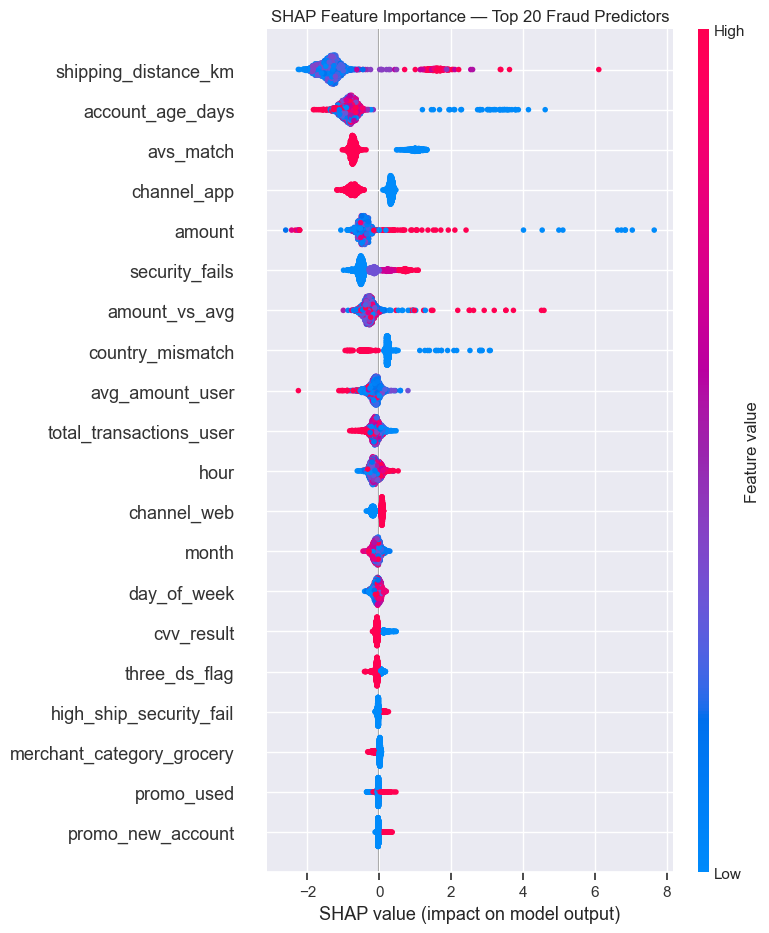

In [23]:
## SHAP Feature Importance
## goal: explain WHICH features drove the model's fraud predictions

import shap

# build explainer using our tuned model
explainer = shap.TreeExplainer(tuned_model)

# calculate SHAP values on test set (use sample for speed)
X_test_sample = X_test.iloc[:2000]
shap_values = explainer.shap_values(X_test_sample)

# plot top 20 most important features
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test_sample, 
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance - Top 20 Fraud Predictors')
plt.tight_layout()
plt.show()

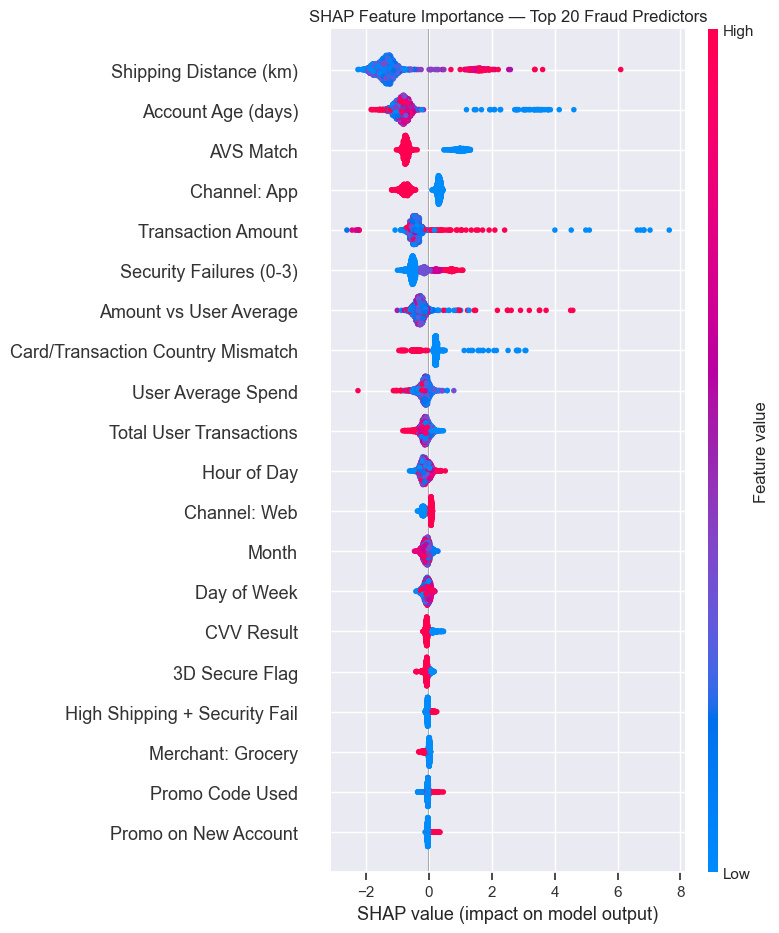

In [27]:
## Rename features for readability
feature_names = {
    'shipping_distance_km': 'Shipping Distance (km)',
    'account_age_days': 'Account Age (days)',
    'avs_match': 'AVS Match',
    'channel_app': 'Channel: App',
    'amount': 'Transaction Amount',
    'security_fails': 'Security Failures (0-3)',
    'amount_vs_avg': 'Amount vs User Average',
    'country_mismatch': 'Card/Transaction Country Mismatch',
    'avg_amount_user': 'User Average Spend',
    'total_transactions_user': 'Total User Transactions',
    'hour': 'Hour of Day',
    'channel_web': 'Channel: Web',
    'month': 'Month',
    'day_of_week': 'Day of Week',
    'cvv_result': 'CVV Result',
    'three_ds_flag': '3D Secure Flag',
    'high_ship_security_fail': 'High Shipping + Security Fail',
    'merchant_category_grocery': 'Merchant: Grocery',
    'promo_used': 'Promo Code Used',
    'promo_new_account': 'Promo on New Account'
}

## rename columns in test sample
X_test_renamed = X_test_sample.rename(columns=feature_names)

## replot SHAP with clean names
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test_renamed,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance - Top 20 Fraud Predictors')
plt.tight_layout()
plt.show()

In [ ]:
Fraudster profile:
- New account (low age)
- Few past transactions
- Low average spend history
- Uses web browser
- Ships far away
- Fails security checks
- Makes unusually large purchase

In [28]:
## Export scored transactions for Tableau
## goal: create a CSV with fraud probability scores for every transaction

# get probabilities for the full dataset
X_full = df.drop(columns=['transaction_id', 'user_id', 'transaction_time', 'is_fraud'])
full_probs = tuned_model.predict_proba(X_full)[:, 1]
full_preds = (full_probs > OPTIMAL_THRESHOLD).astype(int)

# build output dataframe
scored = pd.DataFrame({
    'transaction_id': df['transaction_id'],
    'user_id': df['user_id'],
    'transaction_time': df['transaction_time'],
    'amount': df['amount'],
    'shipping_distance_km': df['shipping_distance_km'],
    'account_age_days': df['account_age_days'],
    'security_fails': df['security_fails'],
    'country_mismatch': df['country_mismatch'],
    'fraud_probability': full_probs.round(4),
    'predicted_fraud': full_preds,
    'actual_fraud': df['is_fraud'],
    'risk_tier': pd.cut(full_probs, 
                        bins=[0, 0.25, 0.5, 0.75, 1.0],
                        labels=['Low', 'Medium', 'High', 'Critical'])
})

# save to outputs folder
scored.to_csv('../outputs/scored_transactions.csv', index=False)
print(f"Exported {len(scored):,} scored transactions")
print(f"\nRisk tier distribution:")
print(scored['risk_tier'].value_counts().sort_index())
print(f"\nSample:")
print(scored.head())

Exported 299,695 scored transactions

Risk tier distribution:
risk_tier
Low         281568
Medium        7974
High          2908
Critical      7245
Name: count, dtype: int64

Sample:
   transaction_id  user_id          transaction_time  amount  \
0               1        1 2024-01-06 04:09:39+00:00   84.75   
1               2        1 2024-01-09 20:13:47+00:00  107.90   
2               3        1 2024-01-12 06:20:11+00:00   92.36   
3               4        1 2024-01-15 17:00:04+00:00  112.47   
4               5        1 2024-01-17 01:27:31+00:00  132.91   

   shipping_distance_km  account_age_days  security_fails  country_mismatch  \
0                370.95               141               0                 0   
1                149.62               141               3                 0   
2                164.08               141               0                 0   
3                397.40               141               0                 0   
4                935.28              

In [30]:
## Clean Test Set Validation Only
## goal: honest unbiased performance on 59,939 unseen transactions

print("=== TEST SET ONLY VALIDATION ===")
print(f"Total test transactions: {len(y_test):,}")
print(f"Actual fraud in test: {y_test.sum():,}")
print(f"Predicted fraud in test: {y_pred_final.sum():,}")
print(f"\nROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"\n{classification_report(y_test, y_pred_final, target_names=['Legit', 'Fraud'])}")

# how many fraud did we catch vs miss
caught = ((y_pred_final == 1) & (y_test == 1)).sum()
missed = ((y_pred_final == 0) & (y_test == 1)).sum()
false_alarms = ((y_pred_final == 1) & (y_test == 0)).sum()

print(f"\n=== BUSINESS IMPACT ===")
print(f"Fraud caught:    {caught:,} ({caught/y_test.sum()*100:.1f}%)")
print(f"Fraud missed:    {missed:,} ({missed/y_test.sum()*100:.1f}%)")
print(f"False alarms:    {false_alarms:,}")
print(f"Transactions needing review: {y_pred_final.sum():,} out of {len(y_test):,}")

=== TEST SET ONLY VALIDATION ===
Total test transactions: 59,939
Actual fraud in test: 1,322
Predicted fraud in test: 1,116

ROC-AUC: 0.9755

              precision    recall  f1-score   support

       Legit       0.99      1.00      1.00     58617
       Fraud       0.91      0.77      0.84      1322

    accuracy                           0.99     59939
   macro avg       0.95      0.88      0.92     59939
weighted avg       0.99      0.99      0.99     59939


=== BUSINESS IMPACT ===
Fraud caught:    1,018 (77.0%)
Fraud missed:    304 (23.0%)
False alarms:    98
Transactions needing review: 1,116 out of 59,939


In [31]:
## Optimize for higher recall
## goal: catch more fraud, accept more false alarms

print(f"{'Threshold':<12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Caught':>10} {'Missed':>10} {'False Alarms':>14}")
print("-" * 80)

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.92]:
    y_pred_t = (y_prob_tuned > threshold).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    caught = ((y_pred_t == 1) & (y_test == 1)).sum()
    missed = ((y_pred_t == 0) & (y_test == 1)).sum()
    fa = ((y_pred_t == 1) & (y_test == 0)).sum()
    print(f"{threshold:<12} {p:>10.2f} {r:>10.2f} {f:>10.2f} {caught:>10,} {missed:>10,} {fa:>14,}")

Threshold     Precision     Recall         F1     Caught     Missed   False Alarms
--------------------------------------------------------------------------------
0.3                0.37       0.89       0.53      1,175        147          1,960
0.4                0.46       0.87       0.60      1,145        177          1,324
0.5                0.56       0.85       0.68      1,123        199            873
0.6                0.67       0.84       0.74      1,108        214            550
0.7                0.74       0.83       0.78      1,091        231            375
0.8                0.81       0.81       0.81      1,071        251            252
0.92               0.91       0.77       0.84      1,018        304             98


In [33]:
## Final Model - Threshold 0.5
## optimized for recall in security operations context

from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

OPTIMAL_THRESHOLD = 0.3

y_pred_final = (y_prob_tuned > OPTIMAL_THRESHOLD).astype(int)

print("=== FINAL MODEL - THRESHOLD 0.5 ===")
print(classification_report(y_test, y_pred_final, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

caught = ((y_pred_final == 1) & (y_test == 1)).sum()
missed = ((y_pred_final == 0) & (y_test == 1)).sum()
false_alarms = ((y_pred_final == 1) & (y_test == 0)).sum()

print(f"\n=== BUSINESS IMPACT ===")
print(f"Fraud caught:    {caught:,} ({caught/y_test.sum()*100:.1f}%)")
print(f"Fraud missed:    {missed:,} ({missed/y_test.sum()*100:.1f}%)")
print(f"False alarms:    {false_alarms:,}")
print(f"Review queue:    {y_pred_final.sum():,} out of {len(y_test):,}")

## re-export scored CSV with new threshold
full_probs = tuned_model.predict_proba(X_full)[:, 1]
full_preds = (full_probs > OPTIMAL_THRESHOLD).astype(int)

scored = pd.DataFrame({
    'transaction_id': df['transaction_id'],
    'user_id': df['user_id'],
    'transaction_time': df['transaction_time'],
    'amount': df['amount'],
    'shipping_distance_km': df['shipping_distance_km'],
    'account_age_days': df['account_age_days'],
    'security_fails': df['security_fails'],
    'country_mismatch': df['country_mismatch'],
    'fraud_probability': full_probs.round(4),
    'predicted_fraud': full_preds,
    'actual_fraud': df['is_fraud'],
    'risk_tier': pd.cut(full_probs,
                        bins=[0, 0.25, 0.5, 0.75, 1.0],
                        labels=['Low', 'Medium', 'High', 'Critical'])
})

scored.to_csv('../outputs/scored_transactions.csv', index=False)
print(f"\nRe-exported {len(scored):,} scored transactions with threshold 0.5")
print(f"\nRisk tier distribution:")
print(scored['risk_tier'].value_counts().sort_index())

=== FINAL MODEL - THRESHOLD 0.5 ===
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.98     58617
       Fraud       0.37      0.89      0.53      1322

    accuracy                           0.96     59939
   macro avg       0.69      0.93      0.75     59939
weighted avg       0.98      0.96      0.97     59939

ROC-AUC: 0.9755

=== BUSINESS IMPACT ===
Fraud caught:    1,175 (88.9%)
Fraud missed:    147 (11.1%)
False alarms:    1,960
Review queue:    3,135 out of 59,939

Re-exported 299,695 scored transactions with threshold 0.5

Risk tier distribution:
risk_tier
Low         281568
Medium        7974
High          2908
Critical      7245
Name: count, dtype: int64


In [35]:
## Cost-Benefit Analysis by Threshold
## goal: find the threshold that maximizes net value to SIS

# assumptions based on our EDA and industry data
avg_fraud_amount = 590        # average fraud transaction value from EDA
analyst_hourly_rate = 35      # estimated analyst hourly rate
review_time_minutes = 15      # average time to review one flagged transaction
review_time_hours = review_time_minutes / 60

print(f"=== COST-BENEFIT ASSUMPTIONS ===")
print(f"Avg fraud value:        ${avg_fraud_amount}")
print(f"Analyst hourly rate:    ${analyst_hourly_rate}")
print(f"Review time per flag:   {review_time_minutes} min")

print(f"\n{'Threshold':<10} {'Caught':>8} {'Missed':>8} {'FalseAlarm':>12} {'FraudSaved':>12} {'AnalystCost':>13} {'NetValue':>12}")
print("-" * 90)

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.92]:
    y_pred_t = (y_prob_tuned > threshold).astype(int)
    
    caught = ((y_pred_t == 1) & (y_test == 1)).sum()
    missed = ((y_pred_t == 0) & (y_test == 1)).sum()
    false_alarms = ((y_pred_t == 1) & (y_test == 0)).sum()
    total_reviews = y_pred_t.sum()
    
    # value recovered from caught fraud
    fraud_saved = caught * avg_fraud_amount
    
    # cost of analyst reviewing all flagged transactions
    analyst_cost = total_reviews * review_time_hours * analyst_hourly_rate
    
    # net value = money saved - analyst cost
    net_value = fraud_saved - analyst_cost
    
    print(f"{threshold:<10} {caught:>8,} {missed:>8,} {false_alarms:>12,} ${fraud_saved:>10,} ${analyst_cost:>11,.0f} ${net_value:>10,.0f}")

print(f"\nNote: scaled to test set (59,939 transactions = 20% of full dataset)")
print(f"Multiply by 5 for full dataset annual estimate")

=== COST-BENEFIT ASSUMPTIONS ===
Avg fraud value:        $590
Analyst hourly rate:    $35
Review time per flag:   15 min

Threshold    Caught   Missed   FalseAlarm   FraudSaved   AnalystCost     NetValue
------------------------------------------------------------------------------------------
0.2           1,202      120        3,083 $   709,180 $     37,494 $   671,686
0.3           1,175      147        1,960 $   693,250 $     27,431 $   665,819
0.4           1,145      177        1,324 $   675,550 $     21,604 $   653,946
0.5           1,123      199          873 $   662,570 $     17,465 $   645,105
0.6           1,108      214          550 $   653,720 $     14,508 $   639,212
0.7           1,091      231          375 $   643,690 $     12,828 $   630,862
0.8           1,071      251          252 $   631,890 $     11,576 $   620,314
0.92          1,018      304           98 $   600,620 $      9,765 $   590,855

Note: scaled to test set (59,939 transactions = 20% of full dataset)
Mul

In [36]:
## Extended threshold analysis - how low can we go?

print(f"{'Threshold':<10} {'Caught':>8} {'Missed':>8} {'FalseAlarm':>12} {'FraudSaved':>12} {'AnalystCost':>13} {'NetValue':>12} {'Precision':>10}")
print("-" * 100)

for threshold in [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]:
    y_pred_t = (y_prob_tuned > threshold).astype(int)
    
    caught = ((y_pred_t == 1) & (y_test == 1)).sum()
    missed = ((y_pred_t == 0) & (y_test == 1)).sum()
    false_alarms = ((y_pred_t == 1) & (y_test == 0)).sum()
    total_reviews = y_pred_t.sum()
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    
    fraud_saved = caught * avg_fraud_amount
    analyst_cost = total_reviews * review_time_hours * analyst_hourly_rate
    net_value = fraud_saved - analyst_cost
    
    print(f"{threshold:<10} {caught:>8,} {missed:>8,} {false_alarms:>12,} ${fraud_saved:>10,} ${analyst_cost:>11,.0f} ${net_value:>10,.0f} {p:>10.2f}")

print(f"\nAt some point analyst cost exceeds fraud saved - that's your floor")

Threshold    Caught   Missed   FalseAlarm   FraudSaved   AnalystCost     NetValue  Precision
----------------------------------------------------------------------------------------------------
0.05          1,269       53        9,397 $   748,710 $     93,328 $   655,382       0.12
0.08          1,256       66        6,704 $   741,040 $     69,650 $   671,390       0.16
0.1           1,249       73        5,730 $   736,910 $     61,066 $   675,844       0.18
0.12          1,239       83        4,928 $   731,010 $     53,961 $   677,049       0.20
0.15          1,220      102        4,073 $   719,800 $     46,314 $   673,486       0.23
0.2           1,202      120        3,083 $   709,180 $     37,494 $   671,686       0.28
0.25          1,185      137        2,437 $   699,150 $     31,692 $   667,458       0.33
0.3           1,175      147        1,960 $   693,250 $     27,431 $   665,819       0.37

At some point analyst cost exceeds fraud saved - that's your floor


In [37]:
## Final Model - Threshold 0.12
## mathematically optimal based on cost-benefit analysis
## maximizes net value at $677,049 per 60k transactions

OPTIMAL_THRESHOLD = 0.12

y_pred_final = (y_prob_tuned > OPTIMAL_THRESHOLD).astype(int)

print("=== FINAL MODEL - THRESHOLD 0.12 ===")
print(classification_report(y_test, y_pred_final, target_names=['Legit', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")

caught = ((y_pred_final == 1) & (y_test == 1)).sum()
missed = ((y_pred_final == 0) & (y_test == 1)).sum()
false_alarms = ((y_pred_final == 1) & (y_test == 0)).sum()
total_reviews = y_pred_final.sum()

fraud_saved = caught * avg_fraud_amount
analyst_cost = total_reviews * review_time_hours * analyst_hourly_rate
net_value = fraud_saved - analyst_cost

print(f"\n=== BUSINESS IMPACT ===")
print(f"Fraud caught:        {caught:,} ({caught/y_test.sum()*100:.1f}%)")
print(f"Fraud missed:        {missed:,} ({missed/y_test.sum()*100:.1f}%)")
print(f"False alarms:        {false_alarms:,}")
print(f"Total reviews:       {total_reviews:,} out of {len(y_test):,}")
print(f"\n=== FINANCIAL IMPACT ===")
print(f"Fraud value saved:   ${fraud_saved:,}")
print(f"Analyst cost:        ${analyst_cost:,.0f}")
print(f"Net value:           ${net_value:,.0f}")
print(f"Annual estimate:     ${net_value*5:,.0f} (full dataset x5)")

## re-export scored CSV with final threshold
X_full = df.drop(columns=['transaction_id', 'user_id', 'transaction_time', 'is_fraud'])
full_probs = tuned_model.predict_proba(X_full)[:, 1]
full_preds = (full_probs > OPTIMAL_THRESHOLD).astype(int)

scored = pd.DataFrame({
    'transaction_id': df['transaction_id'],
    'user_id': df['user_id'],
    'transaction_time': df['transaction_time'],
    'amount': df['amount'],
    'shipping_distance_km': df['shipping_distance_km'],
    'account_age_days': df['account_age_days'],
    'security_fails': df['security_fails'],
    'country_mismatch': df['country_mismatch'],
    'fraud_probability': full_probs.round(4),
    'predicted_fraud': full_preds,
    'actual_fraud': df['is_fraud'],
    'risk_tier': pd.cut(full_probs,
                        bins=[0, 0.25, 0.5, 0.75, 1.0],
                        labels=['Low', 'Medium', 'High', 'Critical'])
})

scored.to_csv('../outputs/scored_transactions.csv', index=False)
print(f"\nRe-exported {len(scored):,} scored transactions with threshold 0.12")
print(f"\nRisk tier distribution:")
print(scored['risk_tier'].value_counts().sort_index())

=== FINAL MODEL - THRESHOLD 0.12 ===
              precision    recall  f1-score   support

       Legit       1.00      0.92      0.96     58617
       Fraud       0.20      0.94      0.33      1322

    accuracy                           0.92     59939
   macro avg       0.60      0.93      0.64     59939
weighted avg       0.98      0.92      0.94     59939

ROC-AUC: 0.9755

=== BUSINESS IMPACT ===
Fraud caught:        1,239 (93.7%)
Fraud missed:        83 (6.3%)
False alarms:        4,928
Total reviews:       6,167 out of 59,939

=== FINANCIAL IMPACT ===
Fraud value saved:   $731,010
Analyst cost:        $53,961
Net value:           $677,049
Annual estimate:     $3,385,244 (full dataset x5)

Re-exported 299,695 scored transactions with threshold 0.12

Risk tier distribution:
risk_tier
Low         281568
Medium        7974
High          2908
Critical      7245
Name: count, dtype: int64
